In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from scipy.signal import wiener, butter, freqs, convolve, freqz, convolve2d
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq, fft2, ifft2
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration
from smooth_POD_ROM.pre_processing import gaussian, gaussian_f, convolve_f, convolve_f2D, smoothen
from smooth_POD_ROM.reduced_order_model import train_ROM, L2_eror
from smooth_POD_ROM.post_processing import post_process
from ezyrb import POD, RBF, Database, Linear, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from datetime import datetime
from scipy.optimize import minimize
#import nlopt

In [2]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Burger/"
# X_train = np.load(pth+"X_train.npy")
# X_test = np.load(pth+"X_test.npy")
X_val = np.load(pth+"X_val.npy")

# mu_train = np.load(pth+"mu_train.npy")
# mu_test = np.load(pth+"mu_test.npy")
mu_val = np.load(pth+"mu_val.npy")[:, None]

# is_inside = mu_val[:, 0]<=0.9
# mu_val = mu_val[is_inside]
# X_val = X_val[:, is_inside]

# print(X_train.shape, X_test.shape, X_val.shape)
# print(mu_train.shape, mu_test.shape, mu_val.shape)

# smooth_ROM_sharpened = np.load(pth+"X_test_sROMs.npy")
# smooth_ROM = np.load(pth+"X_test_sROM.npy")

shape = (257, 257)
x = y = np.linspace(0, 1, 257, endpoint=True)
dx = x[1]-x[0]
sigma = 3.1*dx
brute_force = False
num_iter = 10

In [3]:
X_train = X_val[:, ::19]
mu_train = mu_val[::19, :]
print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())

X_test = X_val[:, ::10]
mu_test = mu_val[::10, :]

is_inside = mu_test[:, 0]<=mu_train[-1, :]
mu_test = mu_test[is_inside]
X_test = X_test[:, is_inside]

is_inside = mu_val[:, 0]<=mu_train[-1, :]
mu_val = mu_val[is_inside]
X_val = X_val[:, is_inside]

print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())

print(X_train.shape, X_test.shape, X_val.shape)
print(mu_train.shape, mu_test.shape, mu_val.shape)

rank = len(mu_train)


(53, 1) (66049, 53) [0.    0.988]
(99, 1) (66049, 99) [0.   0.98]
(66049, 53) (66049, 99) (66049, 989)
(53, 1) (99, 1) (989, 1)


In [4]:
# def train_ROM(mu, X):
#     db = Database(mu[:, None], X.T)
#     pod = POD(method="svd", rank=rank)  # = rom.reduction
#     reg = RegularGrid()  # = rom.approximation
#     rom = ROM(db, pod, reg)
#     rom.fit()
#     # pod.fit(db.snapshots.T)  # performs SVD
#     # reduced_output = pod.transform(db.snapshots.T).T  # transform reduces the given snapshots. = VT.T
#     # reg.fit(db.parameters, reduced_output)  # construct interpolators from points and values!
#     return rom

# def L2_eror(X, X_truth):
#     L2 = np.mean((X-X_truth)**2, axis=0)**.5
#     return L2

# standard ROM approach

0.00444029855155762


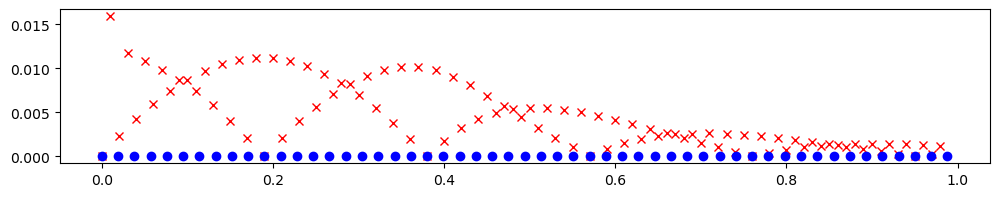

In [5]:
standard_rom = train_ROM(mu_train, X_train, rank=rank)
X_test_ROM = standard_rom.predict(mu_test).T
e_ROM = L2_eror(X_test_ROM, X_test)
mean_eROM = np.mean(e_ROM)

plt.figure(figsize=(12, 2))
plt.plot(mu_test, e_ROM, "rx")
plt.plot(mu_train, np.zeros_like(mu_train), "bo")
print(mean_eROM)

# regularized ROM with Richardson Lucy post processing

In [6]:
# def neares_neighbour(x, x_all):
#     return np.min(np.abs(x-x_all))


# def get_sigma(sigma, mu, mu_train, c):
#     d = neares_neighbour(mu, mu_train)
#     dmu = mu_train[1, 0]-mu_train[0, 0]  # assumes uniform spacing!
#     return sigma*(1+ c * d/dmu)


# def richardson_lucy(x, im_blur, sgm, num_iter=50, truth=None, damping=2):
#     assert len(im_blur.shape)==2, "image needs to be 2D"
#     dx = x[1]-x[0]
#     im_deconv = im_blur.copy()
#     eps = 1e-12  # regularization to avoid 0 division
#     for _ in range(num_iter):
#         #blurred = convolve2d(im_deconv.copy(), psf, boundary='symm', mode='same') + eps
#         #blurred = convolve_f2D(im_deconv, psf_f2D) + eps
#         blurred = gaussian_filter(im_deconv, sigma=sgm/dx, truncate=8)# + eps
#         blurred[np.abs(blurred)<eps] = eps
#         relative_blur = im_blur / blurred
#         #im_deconv *= convolve2d(relative_blur, psf_mirror, boundary='symm', mode='same')
#         #im_deconv *= convolve_f2D(relative_blur, psf_f2D)
#         error_estimate = gaussian_filter(relative_blur, sigma=sgm/dx, truncate=8)
#         if damping:
#             error_estimate[error_estimate>(1+damping)] = 1+damping
#             error_estimate[error_estimate<(1-damping)] = 1-damping
#         im_deconv *= error_estimate
#         if isinstance(truth, np.ndarray):
#             print(_, np.mean((truth-im_deconv.ravel())**2)**.5)
#     return im_deconv


# def post_process(x, data, sigma, c, mu_test, mu_train, num_iter, progress=False):
#     deconvolved = np.empty_like(data)
#     for j in range(len(mu_test)):
#         sgm_est = get_sigma(sigma, mu_test[j], mu_train, c=c)
#         deconvolved[:, j] = richardson_lucy(x, data[:, j].reshape(shape), sgm_est, num_iter).ravel()
#         if progress:
#             print(j, end=", ")
#     return deconvolved

## optimization of hyper parameters using test set

In [7]:

x0 = np.array([3.7*dx, 0.7])

def zielfunktion(params, grad=None):
    # bounds=[(0, 5*dx), (-1, 2)] = [(0, 1), (0, 1)]
    # sigma, c = params[0]*5*dx, params[1]*3-1
    sigma, c = params[0], params[1]
    X_train_s = smoothen(X_train, sigma/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).T
    e_sROM = L2_eror(X_test_sROM, X_test)
    X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter, shape=shape)
    e_sROMs = L2_eror(X_test_sROMs, X_test)
    mean_sROMs = np.mean(e_sROMs)
    s_ = sigma/5/dx
    c_ = (c+1)/3
    
    print("{:.8f}, {:.8f}, {:.8f}".format(sigma/dx, c, mean_sROMs))
    return mean_sROMs

x0 = np.array([2.5*dx, 0.5])
#x0 = np.array([0.45*dx, 0.5])
x0 = np.array([1.12*dx, 1.17])
x0 = np.array([1.0*dx, 0.9])
res = minimize(zielfunktion, x0, method='nelder-mead', bounds=[(0, 5*dx), (-1, 2)], options={'disp': True, "fatol": 1e-5})
#res = minimize(zielfunktion, x0, method='BFGS', options={'disp': True, 'eps': np.array([0.005, 0.005])})


# opt = nlopt.opt("DIRECT", 2)
# opt.set_min_objective(zielfunktion)
# opt.set_lower_bounds([0, -1])
# opt.set_upper_bounds([5*dx, 2])
# opt.set_ftol_rel(1e-6)
# xopt = opt.optimize(x)
# res["x"] = xopt

sigma, c = res["x"]
print(sigma/dx, c)

1.00000000, 0.90000000, 0.00320748
1.05000000, 0.90000000, 0.00324632
1.00000000, 0.94500000, 0.00320969
0.95000000, 0.94500000, 0.00323108
0.97500000, 0.93375000, 0.00321298
1.02500000, 0.91125000, 0.00321720
0.98750000, 0.92812500, 0.00320728
0.98750000, 0.88312500, 0.00321355
0.99687500, 0.92953125, 0.00320703
0.98437500, 0.95765625, 0.00320734
0.98828125, 0.94324219, 0.00320896
0.99218750, 0.92882813, 0.00321663
0.99843750, 0.91476563, 0.00320588
1.00312500, 0.91546875, 0.00320667
1.00468750, 0.90070312, 0.00320618
1.00000000, 0.90000000, 0.00320744
1.00234375, 0.91160156, 0.00320685
1.00156250, 0.90773437, 0.00320595
1.00078125, 0.91511719, 0.00320641
0.99921875, 0.90738281, 0.00321878
1.00039063, 0.91318359, 0.00320561
0.99726563, 0.92021484, 0.00320752
1.00048828, 0.91085449, 0.00320514
1.00244141, 0.90927246, 0.00320635
0.99943848, 0.91339233, 0.00320578
1.00144043, 0.91064575, 0.00322825
0.99993896, 0.91270569, 0.00320660
1.00043945, 0.91201904, 0.00320522
0.99996338, 0.912123

In [8]:
#sigma, c = 1.16194574*dx, 1.16272566
#print(sigma/dx, c)
brute_force = True

In [10]:
if brute_force:
    sigmas = np.arange(0, 2, 0.1)*dx
    cs = np.arange(0.0, 2, 0.1)
    print(len(sigmas), len(cs), len(sigmas)*len(cs), "evaluations")
    # sigmas = [4.3 * dx]
    # cs = [0.3]
    error_matrix_sROM = np.empty((len(sigmas), len(mu_test)))
    error_matrix_sROMs = np.empty((len(sigmas), len(cs), len(mu_test)))
    e_min = mean_eROM
    for i, sigma in enumerate(sigmas):
        X_train_s = smoothen(X_train, sigma/dx, shape)
        smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
        X_test_sROM = smooth_rom.predict(mu_test).T
        e_sROM = L2_eror(X_test_sROM, X_test)
        error_matrix_sROM[i] = e_sROM
        for j, c in enumerate(cs):
            X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter, shape=shape)
            e_sROMs = L2_eror(X_test_sROMs, X_test)
            error_matrix_sROMs[i, j] = e_sROMs
            mean_sROMs = np.mean(e_sROMs)
            print(i*len(cs)+j, i, j, sigmas[i]/dx, cs[j], mean_sROMs)
    #         if np.mean(e_sROMs) < mean_eROM:
    #             print(sigma, c, np.mean(e_ROM), np.mean(e_sROM), np.mean(e_sROMs))

    #         plt.imshow(X_test_ROM[:, 0].reshape(shape))
    #         plt.show()
    #         plt.imshow(X_test_sROM[:, 0].reshape(shape))
    #         plt.show()
    #         plt.imshow(X_test_sROMs[:, 0].reshape(shape))
    #         plt.show()
    np.mean(e_sROMs)

    print(c, np.mean(e_sROMs))

20 20 400 evaluations
0 0 0 0.0 0.0 0.004440298551560219
1 0 1 0.0 0.1 0.004440298551560219
2 0 2 0.0 0.2 0.004440298551560219
3 0 3 0.0 0.30000000000000004 0.004440298551560219
4 0 4 0.0 0.4 0.004440298551560219
5 0 5 0.0 0.5 0.004440298551560219
6 0 6 0.0 0.6000000000000001 0.004440298551560219
7 0 7 0.0 0.7000000000000001 0.004440298551560219
8 0 8 0.0 0.8 0.004440298551560219
9 0 9 0.0 0.9 0.004440298551560219
10 0 10 0.0 1.0 0.004440298551560219
11 0 11 0.0 1.1 0.004440298551560219
12 0 12 0.0 1.2000000000000002 0.004440298551560219
13 0 13 0.0 1.3 0.004440298551560219
14 0 14 0.0 1.4000000000000001 0.004440298551560219
15 0 15 0.0 1.5 0.004440298551560219
16 0 16 0.0 1.6 0.004440298551560219
17 0 17 0.0 1.7000000000000002 0.004440298551560219
18 0 18 0.0 1.8 0.004440298551560219
19 0 19 0.0 1.9000000000000001 0.004440298551560219
20 1 0 0.1 0.0 0.004440298551560219
21 1 1 0.1 0.1 0.004440298551560219
22 1 2 0.1 0.2 0.004440298551560219
23 1 3 0.1 0.30000000000000004 0.00444029855

173 8 13 0.8 1.3 0.0035227525181611504
174 8 14 0.8 1.4000000000000001 0.0034317764694448017
175 8 15 0.8 1.5 0.00341791233252438
176 8 16 0.8 1.6 0.0034638220110238707
177 8 17 0.8 1.7000000000000002 0.0035210563269897507
178 8 18 0.8 1.8 0.0036987098044961647
179 8 19 0.8 1.9000000000000001 0.0037536675092488562
180 9 0 0.9 0.0 0.004535252408902586
181 9 1 0.9 0.1 0.004620876331168648
182 9 2 0.9 0.2 0.0043454862709107036
183 9 3 0.9 0.30000000000000004 0.004160895046647854
184 9 4 0.9 0.4 0.004021200567075708
185 9 5 0.9 0.5 0.0038763500599029044
186 9 6 0.9 0.6000000000000001 0.003835553196984026
187 9 7 0.9 0.7000000000000001 0.0035965992004823597
188 9 8 0.9 0.8 0.003477404528831201
189 9 9 0.9 0.9 0.0033749080944322747
190 9 10 0.9 1.0 0.0033079869214433333
191 9 11 0.9 1.1 0.0032938445074377127
192 9 12 0.9 1.2000000000000002 0.0035231074291421508
193 9 13 0.9 1.3 0.003323264621933667
194 9 14 0.9 1.4000000000000001 0.0034185758067322037
195 9 15 0.9 1.5 0.0036090474524738676
1

345 17 5 1.7000000000000002 0.5 0.0057406342325704
346 17 6 1.7000000000000002 0.6000000000000001 0.006167068563990304
347 17 7 1.7000000000000002 0.7000000000000001 0.0066693235816736056
348 17 8 1.7000000000000002 0.8 0.0072300661892486665
349 17 9 1.7000000000000002 0.9 0.007834855793876846
350 17 10 1.7000000000000002 1.0 0.008472119096353821
351 17 11 1.7000000000000002 1.1 0.009132733373590015
352 17 12 1.7000000000000002 1.2000000000000002 0.009809548564011939
353 17 13 1.7000000000000002 1.3 0.01049696659437592
354 17 14 1.7000000000000002 1.4000000000000001 0.011190602997860767
355 17 15 1.7000000000000002 1.5 0.01188702364542033
356 17 16 1.7000000000000002 1.6 0.012583541848397791
357 17 17 1.7000000000000002 1.7000000000000002 0.01327806180064311
358 17 18 1.7000000000000002 1.8 0.013968957047575408
359 17 19 1.7000000000000002 1.9000000000000001 0.014654975404310624
360 18 0 1.8 0.0 0.005573556207515238
361 18 1 1.8 0.1 0.005477011967175979
362 18 2 1.8 0.2 0.0055003329486

0.004476799804130905
0.00444029855155762 0.011867753745433793
0.003207483266599901 0.023123967405205434
0.7164678803908632


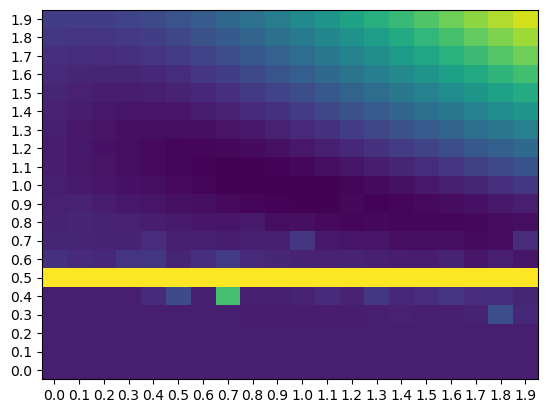

0.004440298551560219
0.005850598415560475
10 9 1.0 0.9


In [16]:
if brute_force:# find best parameter
    mean_eROM = np.mean(e_ROM)
    mean_esROM = np.mean(error_matrix_sROM, axis=-1)
    mean_esROMs = np.mean(error_matrix_sROMs, axis=-1)

    print(mean_eROM)
    print(np.min(mean_esROM), np.max(mean_esROM))
    print(np.min(mean_esROMs), np.max(mean_esROMs))
    print(np.min(mean_esROMs)/mean_eROM)
    fig, ax = plt.subplots()
    dc = cs[1]-cs[0]
    ds = sigmas[1]-sigmas[0]
    ext = (cs[0]-dc/2, cs[-1]+dc/2, (sigmas[0]-ds/2)/dx, (sigmas[-1]+ds/2)/dx)
    ax.imshow(mean_esROMs, interpolation="nearest", origin="lower", vmax=mean_eROM*4.0, extent=ext)
    np.save(pth+"mean_esROMs.npy", mean_esROMs)
    ax.set_xticks(cs)
    ax.set_yticks(sigmas/dx)
    ax.set_aspect("auto")
    plt.show()
    print(np.min(mean_esROMs[0, :]))
    print(np.min(mean_esROMs[-1, :]))
    i, j = np.unravel_index(np.argmin(mean_esROMs, axis=None), mean_esROMs.shape)
    print(i, j, sigmas[i]/dx, cs[j])
    sigma, c = sigmas[i], cs[j]
# why is sigma= 0.5 so bad?

In [15]:
# sigma, c = 4.227671*dx, 0.5075134
# sigma, c = 3.751229*dx, 0.6984642  # 0.8777759682995993. rank 10, n_train=10, v_val=46, n_iter=10

# sigma, c = 3.4*dx, 0.7  # rel improvement: 0.902214
# sigma, c = 4.227671*dx, 0.5075134  # rel improvement: 0.8803. rank 10, n_train=10, v_val=46, n_iter=15
# sigma, c = 1.8534552228069163*dx, 1.2308086725584806 # rel improvement: 0.8160222076576382. rank 19, n_train=19, v_val=46, n_iter=10
# sigma, c = 1.1085238456726074, 1.2304301738739005  # rel improvement: 0.7223638774371589. rank 37, n_train=37, v_val=91, n_iter=10
# sigma, c = 0.4614254379272462, -0.5326662  # rel improvement: 0.9902080455. rank 25, n_train=40, v_val=98, n_iter=10
# sigma, c = 3.825936955299767 0.6320223510887435   # rel improvement: 0.8773397084504572. rank 10, n_train=10, v_val=91, n_iter=10
# sigma, c = 1.1206841573584825 1.170190977863966  # rel improvement: 0.7266813655049182. rank 40, n_train=40, v_val=98, n_iter=10

In [17]:
# run validation:
standard_rom = train_ROM(mu_train, X_train, rank=rank)
X_val_ROM = standard_rom.predict(mu_val).T
e_ROM = L2_eror(X_val_ROM, X_val)
print(np.mean(e_ROM))

X_train_s = smoothen(X_train, sigma/dx, shape)

smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_val_sROM = smooth_rom.predict(mu_val).T
e_sROM = L2_eror(X_val_sROM, X_val)
print(np.mean(e_sROM))

X_val_sROMs = post_process(x, X_val_sROM, sigma, c, mu_val, mu_train, num_iter, progress=True, shape=shape)
e_sROMs = L2_eror(X_val_sROMs, X_val)


print(sigma, c, np.mean(e_sROMs), np.mean(e_sROMs)/np.mean(e_ROM))

0.004476799804130905
0.007018010370390602
0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213

0.00390625 0.9 0.004476799804130905 0.007018010370390602 0.00312832988480495
1.0 0.9 0.6987870848989778
[] []


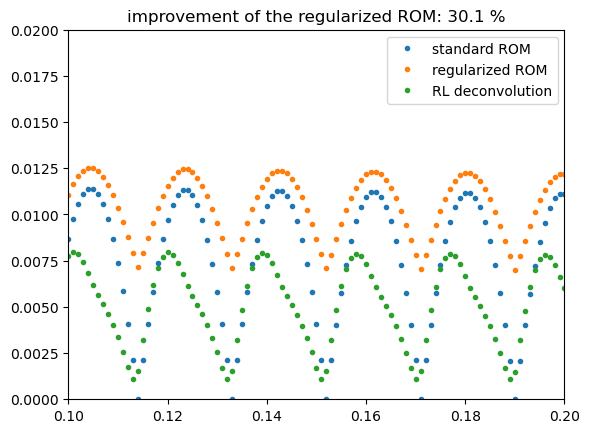

In [18]:
print(sigma, c, np.mean(e_ROM), np.mean(e_sROM), np.mean(e_sROMs))
print(sigma/dx, c, np.mean(e_sROMs)/np.mean(e_ROM))
# 0.025937242937674573
# 0.027494960962479657
# 0.013281250000000003 0.7 0.023400945035938526
plt.plot(mu_val, e_ROM, "C0.", label="standard ROM")
plt.plot(mu_val, e_sROM, "C1.", label="regularized ROM")
plt.plot(mu_val, e_sROMs, "C2.", label="RL deconvolution")
plt.title("improvement of the regularized ROM: {:.1f} %".format(100-100*np.mean(e_sROMs)/np.mean(e_ROM)))
#plt.xlim(0.6, 0.9)
plt.ylim(0, 0.02)
plt.legend()
plt.xlim(.1, 0.2)

indxs = np.arange(len(mu_val))
print(indxs[e_sROMs>0.05], e_sROMs[e_sROMs>0.05])

[0.0095 0.0285 0.0475 0.0665 0.0855 0.1045 0.1235 0.1425 0.1615 0.1805
 0.1995 0.2185 0.2375 0.2565 0.2755 0.2945 0.3135 0.3325 0.3515 0.3705
 0.3895 0.4085 0.4275 0.4465 0.4655 0.4845 0.5035 0.5225 0.5415 0.5605
 0.5795 0.5985 0.6175 0.6365 0.6555 0.6745 0.6935 0.7125 0.7315 0.7505
 0.7695 0.7885 0.8075 0.8265 0.8455 0.8645 0.8835 0.9025 0.9215 0.9405
 0.9595 0.9785]


(0.0, 1.0)

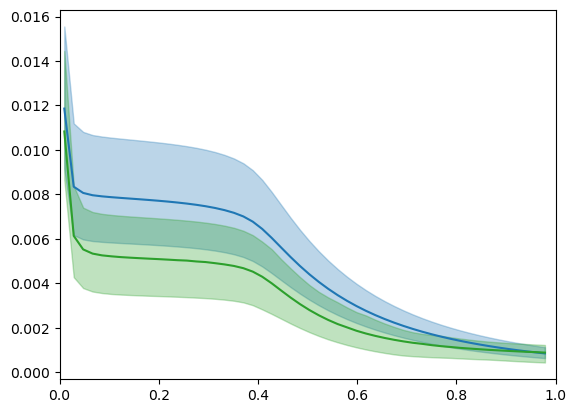

In [19]:
e1u = np.zeros(len(mu_train)-1)
e2u = np.zeros(len(mu_train)-1)
e3u = np.zeros(len(mu_train)-1)
e1 = np.zeros(len(mu_train)-1)
e2 = np.zeros(len(mu_train)-1)
e3 = np.zeros(len(mu_train)-1)
e1l = np.zeros(len(mu_train)-1)
e2l = np.zeros(len(mu_train)-1)
e3l = np.zeros(len(mu_train)-1)

fig, ax = plt.subplots()
for i in range(len(mu_train)-1):
    
    my_bin = (mu_train[i, 0] < mu_val[:, 0]) & (mu_val[:, 0] < mu_train[i+1, 0])

    e1u[i] = np.percentile(e_ROM[my_bin], 75)
    e2u[i] = np.percentile(e_sROM[my_bin], 75)
    e3u[i] = np.percentile(e_sROMs[my_bin], 75)
    
    e1l[i] = np.percentile(e_ROM[my_bin], 25)
    e2l[i] = np.percentile(e_sROM[my_bin], 25)
    e3l[i] = np.percentile(e_sROMs[my_bin], 25)
    
    e1[i] = np.mean(e_ROM[my_bin])
    e2[i] = np.mean(e_sROM[my_bin])
    e3[i] = np.mean(e_sROMs[my_bin])
x = (mu_train[:-1, 0]+mu_train[1:, 0])/2
print(x)
ax.plot(x, e1, "C0-")
#x.plot(x, e2, "C1o")
ax.plot(x, e3, "C2-")
ax.fill_between(x, e1l, e1u, color="C0", alpha=.3)
ax.fill_between(x, e3l, e3u, color="C2", alpha=.3)
ax.set_xlim(0, 1)
# ax.set_ylim(0, 0.014)
# plt.show()

# plt.plot(e2u, "C0--")
# plt.plot(e2, "C0-")
# plt.plot(e2l, "C0--")
# plt.errorbar(x, e1, yerr=[e1u-e1, e1-e1l], color="C0")
#plt.errorbar(x, e2, yerr=[e2u, e2l])
# plt.errorbar(x, e3, yerr=[e3u-e3, e3-e3l], color="C2")

0.011132619607832527
0.006003790058334753
[0.2]


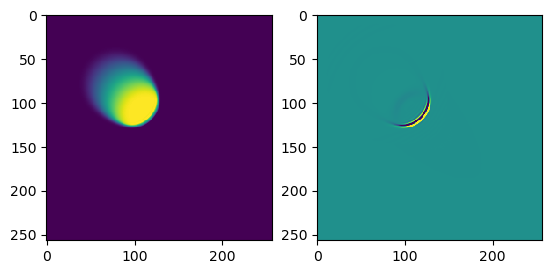

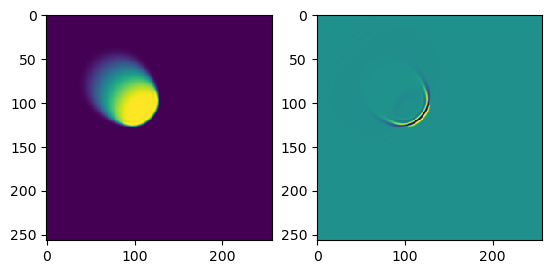

0.010864277101230953
0.005498188813489
[0.201]


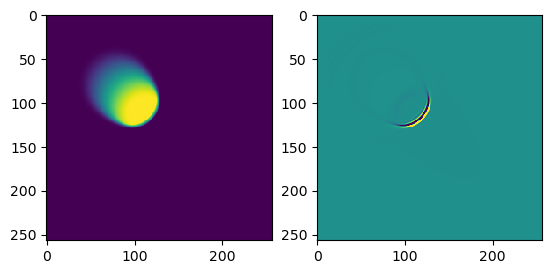

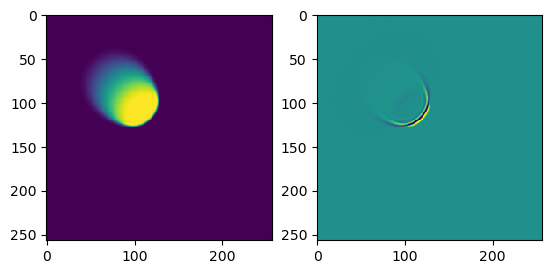

0.010331788720987292
0.005030961365484964
[0.202]


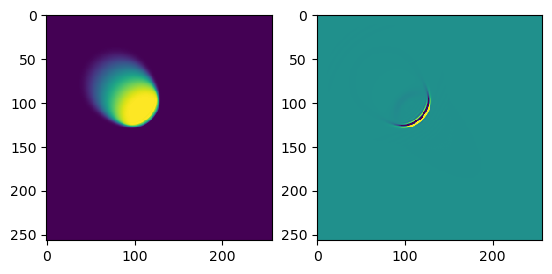

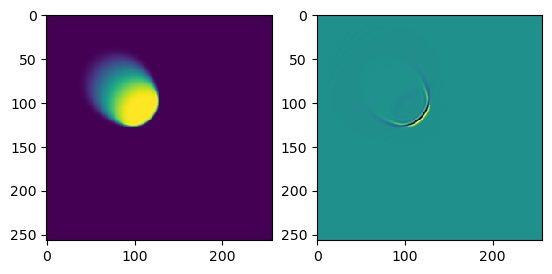

0.0095408615750686
0.004503428929820056
[0.203]


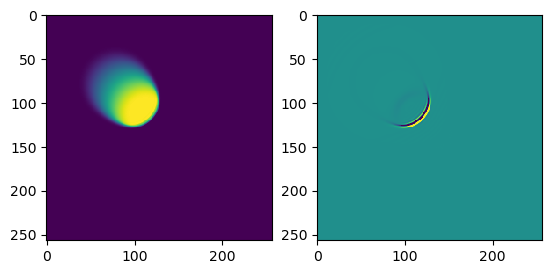

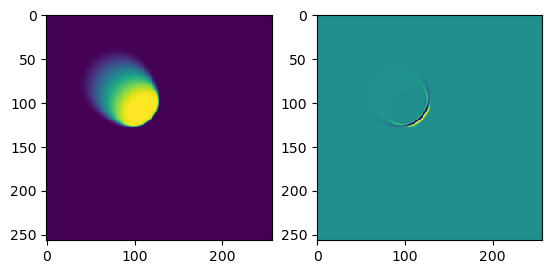

0.008499869770495334
0.0039258040849007815
[0.204]


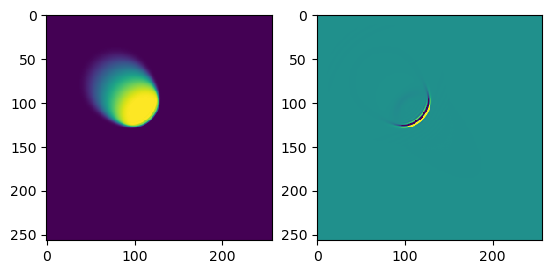

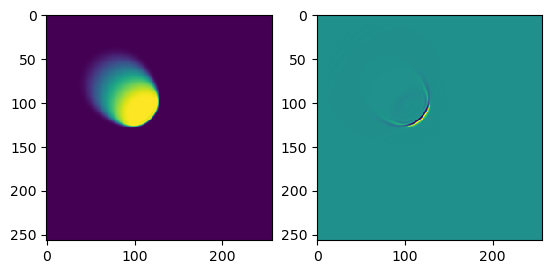

0.007219695786621702
0.0032593672448049406
[0.205]


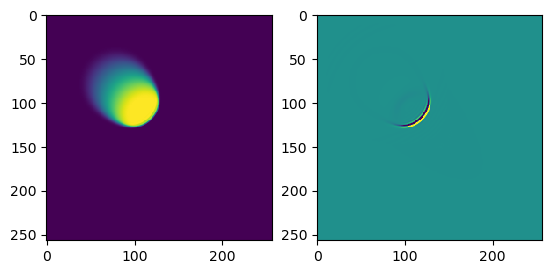

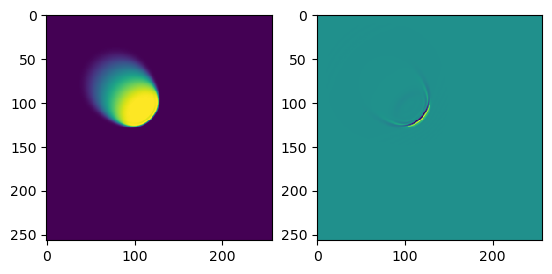

0.0057135255459120115
0.0024986952457968707
[0.206]


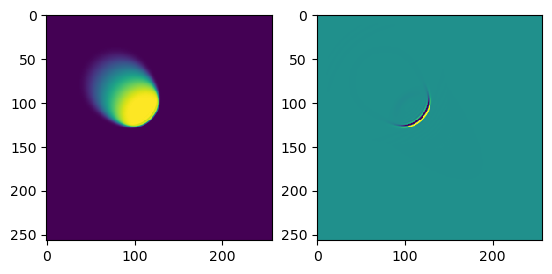

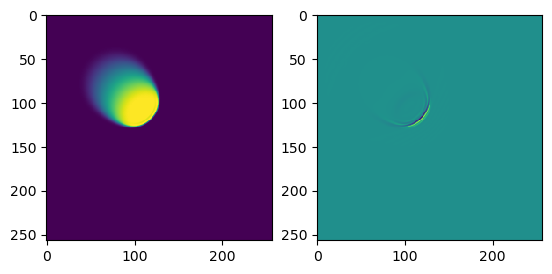

0.003996601198835325
0.0016751919933316588
[0.207]


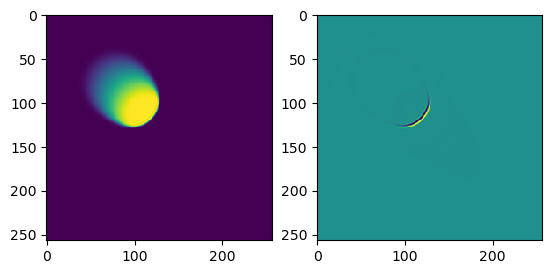

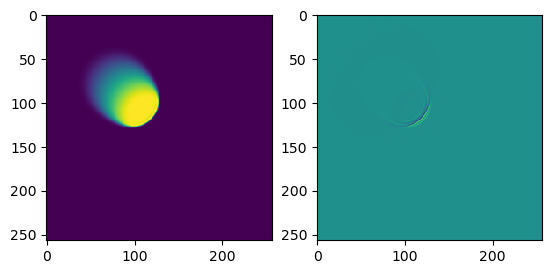

0.002085936443766943
0.001076968730523248
[0.208]


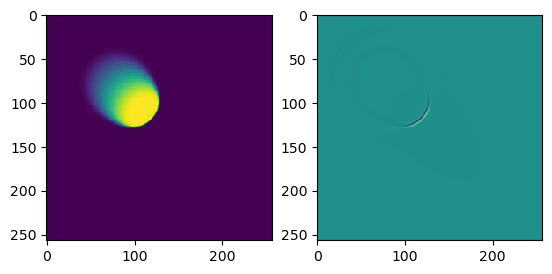

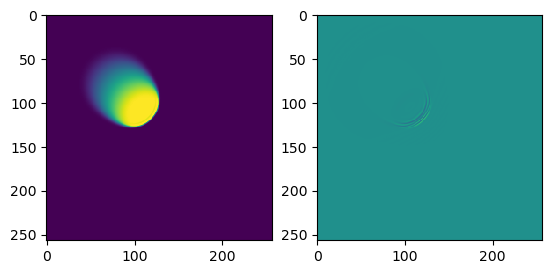

1.6464715090099006e-16
0.0014911474775601992
[0.209]


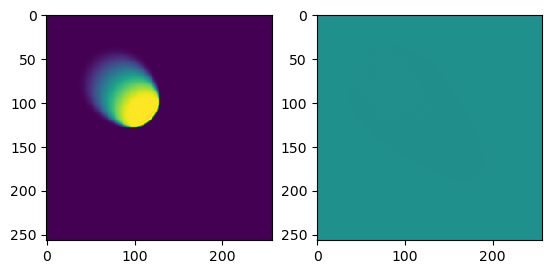

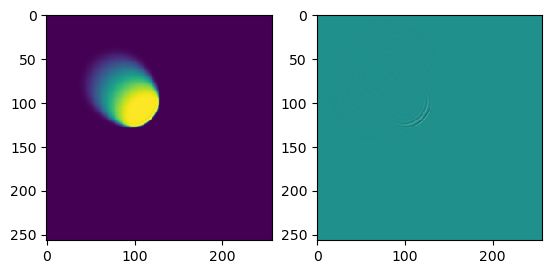

In [20]:
for j in np.arange(200, 210):
    
    print(L2_eror(X_val_ROM[:, j].ravel(), X_val[:, j].ravel()))
    print(L2_eror(X_val_sROMs[:, j].ravel(), X_val[:, j].ravel()))
    print(mu_val[j])
    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(X_val_ROM[:, j].reshape(shape), vmin=0, vmax=1, interpolation="nearest")
    axs[1].imshow((X_val_ROM[:, j]-X_val[:, j]).reshape(shape), vmin=-.1, vmax=.1, interpolation="nearest")
    plt.show()
    fig, axs = plt.subplots(1, 2)
    axs[0].imshow(X_val_sROMs[:, j].reshape(shape), vmin=0, vmax=1, interpolation="nearest")
    axs[1].imshow((X_val_sROMs[:, j]-X_val[:, j]).reshape(shape), vmin=-.1, vmax=.1, interpolation="nearest")
    plt.show()



In [ ]:
def richardson_lucy(x, im_blur, sgm, num_iter=1000, truth=None, damping=2):
    assert len(im_blur.shape)==2, "image needs to be 2D"
    dx = x[1]-x[0]
    im_deconv = im_blur.copy()
    eps = 1e-12  # regularization to avoid 0 division
    for _ in range(num_iter):
        #blurred = convolve2d(im_deconv.copy(), psf, boundary='symm', mode='same') + eps
        #blurred = convolve_f2D(im_deconv, psf_f2D) + eps
        blurred = gaussian_filter(im_deconv, sigma=sgm/dx, truncate=8)# + eps
        blurred[np.abs(blurred)<eps] = eps
        relative_blur = im_blur / blurred
        #im_deconv *= convolve2d(relative_blur, psf_mirror, boundary='symm', mode='same')
        #im_deconv *= convolve_f2D(relative_blur, psf_f2D)
        error_estimate = gaussian_filter(relative_blur, sigma=sgm/dx, truncate=8)
        if damping:
            error_estimate[error_estimate>(1+damping)] = 1+damping
            error_estimate[error_estimate<(1-damping)] = 1-damping
        im_deconv *= error_estimate
        if isinstance(truth, np.ndarray):
            print(_, np.mean((truth-im_deconv.ravel())**2)**.5)
    return im_deconv

In [ ]:
j = 476   

sgm_est = get_sigma(sigma, mu_val[j], mu_train, c=c)
deconvolved_rl = richardson_lucy(x, X_val_sROM[:, j].reshape(shape), sgm_est, num_iter=50, damping=1)

print(mu_val[j])
plt.imshow(X_val_ROM[:, j].reshape(shape)-deconvolved_rl.reshape(shape), vmin=-.1, vmax=.1, interpolation="nearest")
plt.show()

print(L2_eror(X_val_ROM[:, j].ravel(), X_val[:, j].ravel()))
print(L2_eror(deconvolved_rl.ravel(), X_val[:, j].ravel()))

# plt.imshow(X_val_ROM[:, j].reshape(shape), vmin=0, vmax=1, interpolation="nearest")
# plt.show()

# plt.imshow(X_val[:, j].reshape(shape), vmin=0, vmax=1, interpolation="nearest")
# plt.show()

RL: The algorithm can produce artifacts, especially in the presence of high noise levels or incorrect PSF. It also requires careful selection of the number of iterations to avoid over-amplifying noise.

In [ ]:
from scipy.ndimage import convolve
import numpy as np
import cv2
image = X_val[:, j].reshape(shape)


kernel1D = cv2.getGaussianKernel(51, sigma)
psf = np.outer(kernel1D, kernel1D)
# print(np.sum(psf))
# psf /= np.sum(psf)
# plt.imshow(psf)
# plt.show()
print(np.sum(psf))

# Simulate a blurred image
blurred = X_val_sROM[:, j].reshape(shape)

# Apply Wiener Deconvolution
deconvolved_w = wiener(blurred, mysize=psf.shape, noise=1e-6)
deconvolved_rl = richardson_lucy(x, X_val_sROM[:, j].reshape(shape), sgm_est, num_iter=50).reshape(shape)
print(L2_eror(blurred.ravel(), image.ravel()))
print(L2_eror(deconvolved_w.ravel(), image.ravel()))
print(L2_eror(deconvolved_rl.ravel(), image.ravel()))

plt.imshow(blurred, vmin=0, vmax=1)
plt.show()
plt.imshow(deconvolved_w, vmin=0, vmax=1)
plt.show()
plt.imshow(image, vmin=0, vmax=1)
plt.show()